<a href="https://colab.research.google.com/github/MarcelinaBytes/AIHC5020/blob/main/AIHC5020_FinalExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Final Exam
''https://github.com/AIHC5020/final_exam''

##Problem 1: Summarizing Data Types in Python

In [1]:
#import Pandas

import pandas as pd

In [4]:
#define data as a list of dictionaries

data = [
    {
        "name": "Integer",
        "python_symbol": "int",
        "example": str(25),
        "falsy_value": 0,
        "usage": "Represents whole numbers"
    },
    {
        "name": "Float",
        "python_symbol": "float",
        "example": str(3.14),
        "falsy_value": 0.0,
        "usage": "Represents decimal numbers"
    },
    {
        "name": "String",
        "python_symbol": "str",
        "example": str("hello"),
        "falsy_value": "",
        "usage": "Represents text data"
    },
    {
        "name": "Boolean",
        "python_symbol": "bool",
        "example": str(True),
        "falsy_value": False,
        "usage": "Represents True or False values"
    },
    {
        "name": "NoneType",
        "python_symbol": "NoneType",
        "example": str(None),
        "falsy_value": None,
        "usage": "Represents absence of a value"
    },
    {
        "name": "Complex",
        "python_symbol": "complex",
        "example": str(2 + 3j),
        "falsy_value": 0j,
        "usage": "Represents complex numbers"
    },
    {
        "name": "List",
        "python_symbol": "list",
        "example": str([1, 2, 3]),
        "falsy_value": [],
        "usage": "Ordered, mutable collection of items"
    },
    {
        "name": "Tuple",
        "python_symbol": "tuple",
        "example": str((1, 2, 3)),
        "falsy_value": (),
        "usage": "Ordered, immutable collection of items"
    },
    {
        "name": "Dictionary",
        "python_symbol": "dict",
        "example": str({"a": 1, "b": 2}),
        "falsy_value": {},
        "usage": "Stores key-value pairs"
    }
]

In [9]:
#create the Data Frame

df = pd.DataFrame(data)

In [12]:
#show complete data frame

df

,name,python_symbol,example,falsy_value,usage
0,Integer,int,25,0,Represents whole numbers
1,Float,float,3.14,0.0,Represents decimal numbers
2,String,str,hello,,Represents text data
3,Boolean,bool,True,False,Represents True or False values
4,NoneType,NoneType,None,None,Represents absence of a value
5,Complex,complex,(2+3j),0j,Represents complex numbers
6,List,list,"[1, 2, 3]",[],"Ordered, mutable collection of items"
7,Tuple,tuple,"(1, 2, 3)",(),"Ordered, immutable collection of items"
8,Dictionary,dict,"{'a': 1, 'b': 2}",{},Stores key-value pairs


##Problem 2: Chat Log Data

In [15]:
#Install and import libraries

!pip -q install google-cloud-storage

In [16]:
import json
import pandas as pd
from io import StringIO
from google.cloud import storage
from google.auth.credentials import AnonymousCredentials
from datetime import datetime, timezone

In [17]:
#create an anonymous GCS client (public bucket)

storage_client = storage.Client(credentials=AnonymousCredentials())
bucket = storage_client.bucket("cloud-samples-data")

In [18]:
def micros_to_datetime_string(micros: int) -> str:
    # micros → seconds
    dt = datetime.fromtimestamp(micros / 1_000_000, tz=timezone.utc)
    return dt.strftime("%Y-%m-%d %H:%M:%S")

In [21]:
def load_chat_log(chat_log_id: int, bucket, prefix: str = "ccai/sample-chat-logs/"):
    """
    Loads a chat log JSON from GCS and returns a long-format pandas DataFrame.

    Parameters
    ----------
    chat_log_id : int
        Integer ID associated with the chat log file.
    bucket : google.cloud.storage.bucket.Bucket
        GCS bucket object.
    prefix : str
        Prefix where chat logs are stored.

    Returns
    -------
    pandas.DataFrame or None
        Long-format DataFrame of chat messages, or None if not found.
    """

    # 1) Locate candidate files under the prefix
    blobs = bucket.list_blobs(prefix=prefix)

    matched_blob = None
    id_str = str(chat_log_id)

    for blob in blobs:
        # Common patterns might include ".../101.json" or ".../chat_101.json"
        name = blob.name
        if name.endswith(f"{id_str}.json") or name.endswith(f"{id_str}.JSON"):
            matched_blob = blob
            break
        if f"_{id_str}.json" in name or f"/{id_str}.json" in name:
            matched_blob = blob
            break

    # 2) If file not found: print message + return None
    if matched_blob is None:
        print(f"No chat log file found for id {chat_log_id} in prefix '{prefix}'.")
        return None

    # 3) Download and parse JSON
    raw_text = matched_blob.download_as_text()
    chat_obj = json.loads(raw_text)

    # 4) Extract messages into long-table rows
    rows = []

    # The JSON might be:
    # - a list of message objects
    # - or a dict with a key like "messages" or "chat" or "entries"
    if isinstance(chat_obj, list):
        messages = chat_obj
    elif isinstance(chat_obj, dict):
        # try common keys
        for key in ["messages", "chat", "entries", "events", "data"]:
            if key in chat_obj and isinstance(chat_obj[key], list):
                messages = chat_obj[key]
                break
        else:
            # fallback: if dict values contain a list, grab first list-like
            messages = next((v for v in chat_obj.values() if isinstance(v, list)), [])
    else:
        messages = []

    for msg in messages:
        if not isinstance(msg, dict):
            continue

        # timestamp could be under different keys
        ts = msg.get("timestamp") or msg.get("time") or msg.get("ts") or msg.get("create_time")

        # Some logs nest content under "message"
        text = msg.get("text") or msg.get("message") or msg.get("content") or msg.get("utterance")

        # Sender might be under these keys
        sender = msg.get("sender") or msg.get("author") or msg.get("user") or msg.get("speaker")

        # Convert timestamp if present (expected unix microseconds)
        ts_str = None
        if ts is not None:
            try:
                ts_int = int(ts)
                ts_str = micros_to_datetime_string(ts_int)
            except Exception:
                ts_str = str(ts)

        rows.append({
            "chat_log_id": chat_log_id,
            "datetime_utc": ts_str,
            "sender": sender,
            "message": text
        })

    # 5) Create DataFrame
    df = pd.DataFrame(rows)

    # Optional: sort by time if available
    if "datetime_utc" in df.columns:
        # sorting strings works because format is YYYY-mm-dd HH:MM:SS
        df = df.sort_values("datetime_utc", ascending=True).reset_index(drop=True)

    return df

In [22]:
#run it for the chat log

chat_101_df = load_chat_log(101, bucket)

chat_101_df

,chat_log_id,datetime_utc,sender,message
0,101,None,None,"Hello, how can I assist you today?"
1,101,None,None,"Hi, I'm having an issue with my laptop"
2,101,None,None,Sorry to hear. Can you tell me what the proble...
3,101,None,None,The laptop is not connecting to the internet. ...
4,101,None,None,Can you give me more details about the problem...
5,101,None,None,The problem with the laptop is still happening...
6,101,None,None,And what is the status shown in the settings o...
7,101,None,None,Warning: No available storage. Your computer's...
8,101,None,None,Can you tell me your account number?
9,101,None,None,"Sure, it's 407106565"


In [23]:
#first 2 rows

chat_101_df.head()

,chat_log_id,datetime_utc,sender,message
0,101,None,None,"Hello, how can I assist you today?"
1,101,None,None,"Hi, I'm having an issue with my laptop"
2,101,None,None,Sorry to hear. Can you tell me what the proble...
3,101,None,None,The laptop is not connecting to the internet. ...
4,101,None,None,Can you give me more details about the problem...


##Problem 3: Chest X-ray DICOM manifest

In [24]:
#mount colab

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
#install and import libraries

!pip -q install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.6 MB/s eta 0:00:00


In [26]:
import os
import pandas as pd
import pydicom

In [27]:
#function

def build_dicom_manifest(dicom_root: str) -> pd.DataFrame:
    """
    Build a manifest DataFrame describing DICOM series in a folder.

    Parameters
    ----------
    dicom_root : str
        Path to folder containing DICOM files.

    Returns
    -------
    pandas.DataFrame
        Manifest with one row per DICOM series.
    """

    series_dict = {}

    for root, _, files in os.walk(dicom_root):
        for fname in files:
            fpath = os.path.join(root, fname)

            try:
                ds = pydicom.dcmread(fpath, stop_before_pixels=True)
            except Exception:
                # Skip non-DICOM or unreadable files
                continue

            # Required identifiers
            series_uid = getattr(ds, "SeriesInstanceUID", None)
            study_uid = getattr(ds, "StudyInstanceUID", None)

            if series_uid is None:
                continue

            # Initialize series entry if first time seen
            if series_uid not in series_dict:
                series_dict[series_uid] = {
                    "series_uid": series_uid,
                    "study_uid": study_uid,
                    "patient_id": getattr(ds, "PatientID", None),
                    "study_date": getattr(ds, "StudyDate", None),
                    "modality": getattr(ds, "Modality", None),
                    "num_images": 0,
                    "series_directory": root
                }

            # Increment image count
            series_dict[series_uid]["num_images"] += 1

    # Convert to DataFrame
    manifest_df = pd.DataFrame(series_dict.values())

    return manifest_df

In [28]:
dicom_path = "/content/drive/MyDrive/AIHC5020/dicom/chest_xray"

manifest_df = build_dicom_manifest(dicom_path)

In [29]:
manifest_df.head()

,series_uid,study_uid,patient_id,study_date,modality,num_images,series_directory
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.140111454550...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213083367261...,LIDC-IDRI-0015,20000101,DX,1,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.541650212189...,1.3.6.1.4.1.14519.5.2.1.6279.6001.675114969651...,LIDC-IDRI-0023,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.334422875695...,1.3.6.1.4.1.14519.5.2.1.6279.6001.302822025885...,LIDC-IDRI-0040,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.140614242738...,1.3.6.1.4.1.14519.5.2.1.6279.6001.269469709045...,LIDC-IDRI-0014,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.239368516910...,1.3.6.1.4.1.14519.5.2.1.6279.6001.333103030188...,LIDC-IDRI-0012,20000101,DX,2,/content/drive/MyDrive/AIHC5020/dicom/chest_xr...


##Problem 4: Visualizing Chest X-Rays

In [30]:
#imports
import os
import matplotlib.pyplot as plt
import pydicom

In [31]:
#function

def visualize_patient_xrays(patient_id: str, manifest_df):
    """
    Visualize all DICOM instances for a given patient ID.

    Parameters
    ----------
    patient_id : str
        Patient ID to visualize.
    manifest_df : pandas.DataFrame
        Manifest DataFrame from Problem 3.

    Returns
    -------
    None
    """

    # Filter manifest for the patient
    patient_series = manifest_df[manifest_df["patient_id"] == patient_id]

    if patient_series.empty:
        print(f"No DICOM series found for patient ID: {patient_id}")
        return None

    for _, row in patient_series.iterrows():
        series_dir = row["series_directory"]
        series_uid = row["series_uid"]

        # Collect DICOM files in this series directory
        dicom_files = []
        for fname in os.listdir(series_dir):
            fpath = os.path.join(series_dir, fname)
            try:
                ds = pydicom.dcmread(fpath)
                dicom_files.append(ds)
            except Exception:
                continue

        if not dicom_files:
            continue

        num_images = len(dicom_files)

        # Create figure layout
        fig, axes = plt.subplots(
            1, num_images,
            figsize=(4 * num_images, 4),
            squeeze=False
        )

        fig.suptitle(f"Patient: {patient_id} | Series: {series_uid}", fontsize=12)

        for idx, ds in enumerate(dicom_files):
            ax = axes[0, idx]
            ax.imshow(ds.pixel_array, cmap="gray")
            ax.axis("off")

        plt.show()

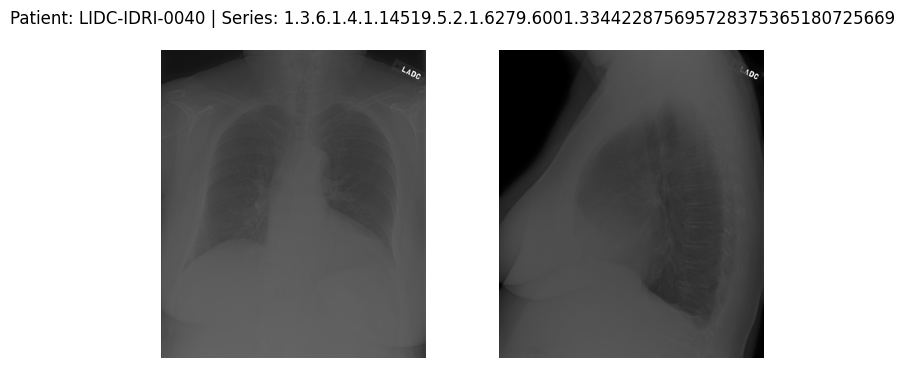

In [32]:
# Run the function
visualize_patient_xrays("LIDC-IDRI-0040", manifest_df)